# Build the training tiles

Turning the AOI into a dataset the U-Net can eat: paired **image tiles** (6 Sentinel-2 bands) and **mask tiles** (the 5-class WorldCover label), 256×256 px each.

**Two parts, with a wait between them:**
- **Part A** stacks the 2021 composite + labels and exports it to Google Drive as a GeoTIFF (a GEE batch task).
- **Part B** (run *after* the export finishes) reads the GeoTIFF in Colab and slices it into tiles, filtering cloud-holes and splitting train/val.

Why export-then-tile instead of downloading tiles directly: the heavy GEE export happens once, and can re-tile (different size, overlap, filters) as many times as you like without touching GEE again.

# Part A: Exporting the stacked image to Drive

In [1]:
!pip install -q earthengine-api

In [2]:
import ee
from IPython.display import Image as IPyImage, display

PROJECT = "landcover-riau"
ee.Authenticate()
ee.Initialize(project=PROJECT)


def show(image, vis, region, dims=500, label=None):
    params = dict(vis); params["region"] = region; params["dimensions"] = dims
    if label:
        print(label)
    display(IPyImage(url=image.getThumbURL(params)))

In [3]:
# --- config (mirrors configs/config.py) ---
AOI_BBOX = [102.9, -0.6, 103.4, -0.1]      # Indragiri coast
region = ee.Geometry.Rectangle(AOI_BBOX)

S2_BANDS = ["B2", "B3", "B4", "B8", "B11", "B12"]
CLASSES = {0: "forest", 1: "agriculture", 2: "urban", 3: "water", 4: "bare"}
NATIVE = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]
TO5    = [ 0,  1,  1,  1,  2,  4,  4,  3,  1,  0,   4]

LABEL_YEAR = 2021
EXPORT_CRS = "EPSG:32648"      # UTM zone 48N -> square 10 m pixels over Indragiri
DRIVE_FOLDER = "landcover_riau"
PREFIX = "indragiri_2021_stack"

In [4]:
def s2_composite(year, reg, window=("06-01", "09-30"), threshold=0.6):
    start, end = f"{year}-{window[0]}", f"{year}-{window[1]}"
    s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
          .filterBounds(reg).filterDate(start, end))
    cs = ee.ImageCollection("GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED")
    s2 = (s2.linkCollection(cs, ["cs_cdf"])
            .map(lambda i: i.updateMask(i.select("cs_cdf").gte(threshold))))
    return s2.median().clip(reg)


def labels_for(reg):
    wc = ee.ImageCollection("ESA/WorldCover/v200").first().clip(reg)
    return wc.select("Map").remap(NATIVE, TO5).rename("class")

## Build the 8-band stack

6 imagery bands + 1 label band + 1 **valid** band. The valid band is 1 where *all* six S2 bands have data and 0 where the cloud mask emptied the pixel. I'll use it in Part B to throw away tiles full of cloud-holes. `unmask(0)` then fills masked pixels with 0 so the export is a clean rectangle.

In [5]:
img = s2_composite(LABEL_YEAR, region).select(S2_BANDS)
valid = img.mask().reduce(ee.Reducer.min()).rename("valid")   # 1 if all bands present

stack = img.addBands(labels_for(region)).addBands(valid).unmask(0).toFloat()
print("stack bands:", stack.bandNames().getInfo())

stack bands: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'class', 'valid']


## Cloud-hole check before exporting

The Indragiri coast is tidal and cloudy. If valid-data coverage is low, widen the window (e.g. `("05-01", "10-31")`) and rebuild before exporting.

In [6]:
cov = valid.reduceRegion(ee.Reducer.mean(), region, scale=30, maxPixels=1e10).getInfo()["valid"]
print(f"valid-data coverage: {100 * cov:.1f}%   (aim for >90%)")

rgb = {"bands": ["B4", "B3", "B2"], "min": 0, "max": 3000}
show(img, rgb, region=region, label="2021 composite — look for black cloud-holes")

valid-data coverage: 99.9%   (aim for >90%)
2021 composite — look for black cloud-holes


In [7]:
task = ee.batch.Export.image.toDrive(
    image=stack,
    description=PREFIX,
    folder=DRIVE_FOLDER,
    fileNamePrefix=PREFIX,
    region=region,
    scale=10,
    crs=EXPORT_CRS,
    maxPixels=1e10,
)
task.start()
print("export started:", task.id)

export started: BRCTJBFPAFSXTTTZYL7D4OMB


# Part B: Slice into tiles

**Run this only once the export shows COMPLETED** and the GeoTIFF(s) are in
`Drive/landcover_riau/`. GEE may split a big export into several `...-0000000000-0000000000.tif` files; just tile each one.

In [8]:
!pip install -q rasterio
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [9]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import glob
print("top level:", glob.glob("/content/drive/MyDrive/*"))
print("recursive:", glob.glob("/content/drive/MyDrive/**/indragiri_2021_stack*.tif", recursive=True))

Mounted at /content/drive
top level: ['/content/drive/MyDrive/Classroom', '/content/drive/MyDrive/chapter10ws3.gdoc', '/content/drive/MyDrive/chapter10ws2.gdoc', '/content/drive/MyDrive/chapter10ws4.gdoc', '/content/drive/MyDrive/chapter10ws5.gdoc', '/content/drive/MyDrive/chapter10ws6.gdoc', '/content/drive/MyDrive/PURE CHEMISTRY.pdf', '/content/drive/MyDrive/acids and based ws 1.pdf', '/content/drive/MyDrive/acids and bases ws 2.pdf', '/content/drive/MyDrive/Topic 7 - Acids & Bases_with blanks.pdf', '/content/drive/MyDrive/Topic 7 - Acids & Bases_with blanks.gdoc', '/content/drive/MyDrive/Copy of Sec 4 final revision paper 1A_student_280820.docx', '/content/drive/MyDrive/Copy of Sec 4 final revision paper 1b_student_310820.docx', '/content/drive/MyDrive/L44 CHEMISTRY PRACTICAL REVISION 2.gdoc', '/content/drive/MyDrive/PW report: draft 1 (chapter 1&2).gdoc', '/content/drive/MyDrive/gp t2w8.gdoc', '/content/drive/MyDrive/gp t2w8.docx', '/content/drive/MyDrive/RJC PW 23S06P (dialects).g

In [10]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import glob
print("folder:", glob.glob("/content/drive/MyDrive/landcover_riau/*"))

Mounted at /content/drive
folder: ['/content/drive/MyDrive/landcover_riau/tiles', '/content/drive/MyDrive/landcover_riau/indragiri_2021_stack.tif', '/content/drive/MyDrive/landcover_riau/unet_best.pt']


In [11]:
import glob, os, numpy as np, rasterio

DRIVE = f"/content/drive/MyDrive/{DRIVE_FOLDER}"
files = sorted(glob.glob(f"{DRIVE}/{PREFIX}*.tif"))
print(f"found {len(files)} export file(s):")
for f in files:
    print(" ", os.path.basename(f))

# tiling params
TILE = 256          # 256 px * 10 m = 2.56 km per tile
STRIDE = 256        # no overlap; set to 128 to ~4x the tiles via overlap
VALID_FRAC = 0.95   # keep a tile only if >=95% of its pixels have real imagery
VAL_FRACTION_X = 0.2  # rightmost 20% (by column) -> validation, to limit leakage

found 1 export file(s):
  indragiri_2021_stack.tif


### Tile + split

I slide a 256×256 window across each export file, drop tiles that are mostly cloud-hole, and assign each tile to **train** or **val** by its *position*: the rightmost strip of the AOI becomes validation. A spatial split (rather than random) keeps adjacent, correlated tiles out of both sets. Otherwise, the model can 'memorise' a neighbour and val scores lie.

In [12]:
OUT = f"{DRIVE}/tiles"
for split in ("train", "val"):
    os.makedirs(f"{OUT}/{split}", exist_ok=True)

n = {"train": 0, "val": 0}
for fp in files:
    with rasterio.open(fp) as src:
        arr = src.read()                      # (8, H, W): 6 img + class + valid
    arr = np.nan_to_num(arr, nan=0.0)         # corners outside the AOI polygon export as NaN -> 0
    image_bands = arr[:6].astype(np.float32)  # B2,B3,B4,B8,B11,B12
    mask_band   = arr[6].astype(np.uint8)     # class 0..4
    valid_band  = arr[7]                       # NaN corners are now 0 -> tile gets skipped below
    H, W = mask_band.shape
    x_cut = (1 - VAL_FRACTION_X) * W

    for y in range(0, H - TILE + 1, STRIDE):
        for x in range(0, W - TILE + 1, STRIDE):
            v = valid_band[y:y + TILE, x:x + TILE]
            if v.mean() < VALID_FRAC:
                continue
            im = image_bands[:, y:y + TILE, x:x + TILE]   # (6, 256, 256)
            ms = mask_band[y:y + TILE, x:x + TILE]          # (256, 256)
            split = "val" if x >= x_cut else "train"
            stem = os.path.basename(fp)[:-4]
            np.savez_compressed(f"{OUT}/{split}/{stem}_{y}_{x}.npz", image=im, mask=ms)
            n[split] += 1

print("tiles written:", n)

tiles written: {'train': 378, 'val': 63}


### Class distribution + loss weights

Confirm the imbalance expected (~forest-dominated) and compute **inverse-frequency class weights**. I'll feed these to the U-Net's loss in Notebook 5 so it doesn't just predict 'forest' everywhere.

In [13]:
from collections import Counter
counts = Counter()
for fp in glob.glob(f"{OUT}/train/*.npz"):
    counts.update(np.load(fp)["mask"].ravel().tolist())

total = sum(counts.values())
print("train-set pixel mix:")
for c in range(5):
    pct = 100 * counts.get(c, 0) / total
    print(f"  {CLASSES[c]:12s} {pct:5.1f}%")

# inverse-frequency weights, normalised to mean 1
raw = {c: total / (5 * counts[c]) for c in range(5) if counts.get(c, 0)}
mean_w = sum(raw.values()) / len(raw)
weights = {c: round(w / mean_w, 3) for c, w in raw.items()}
print("\nclass weights for Step 4:", weights)

train-set pixel mix:
  forest        87.1%
  agriculture    9.1%
  urban          0.6%
  water          3.3%
  bare           0.0%

class weights for Step 4: {0: 0.001, 1: 0.008, 2: 0.132, 3: 0.022, 4: 4.837}


### Preview a few tiles

Sanity check that image and mask line up before trusting the dataset.

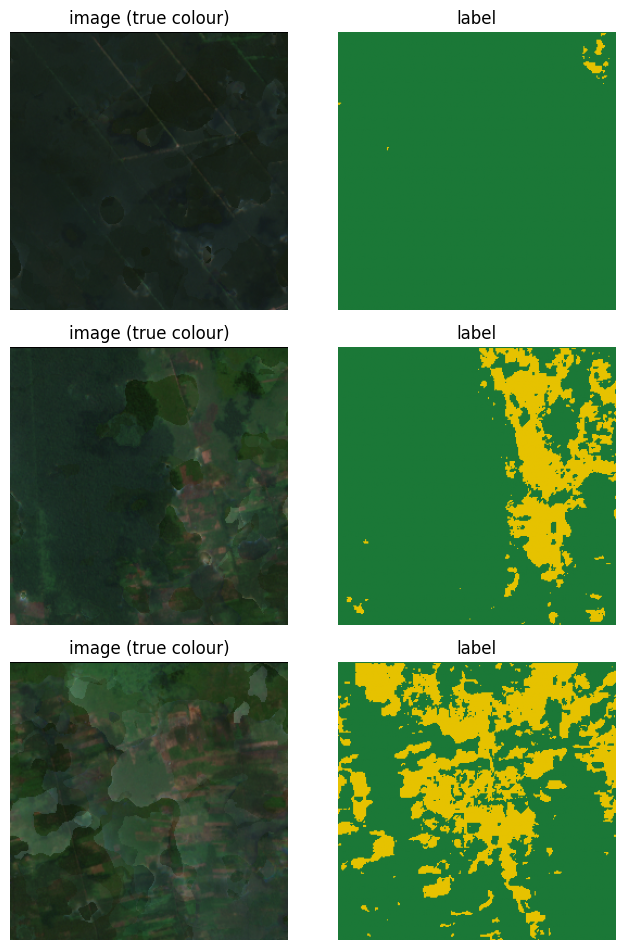

In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#1b7837", "#e6c200", "#d7191c", "#2c7fb8", "#bdbdbd"])
sample = sorted(glob.glob(f"{OUT}/train/*.npz"))[:3]

fig, axes = plt.subplots(len(sample), 2, figsize=(7, 3.2 * len(sample)))
for row, fp in enumerate(sample):
    d = np.load(fp)
    rgb = d["image"][[2, 1, 0]].transpose(1, 2, 0) / 3000.0   # B4,B3,B2
    axes[row, 0].imshow(np.clip(rgb, 0, 1)); axes[row, 0].set_title("image (true colour)")
    axes[row, 1].imshow(d["mask"], cmap=cmap, vmin=0, vmax=4); axes[row, 1].set_title("label")
    for ax in axes[row]:
        ax.axis("off")
plt.tight_layout(); plt.show()

In [15]:
import numpy as np
# merge near-absent 'bare' (~0.02%) into agriculture -> 4 classes
m = {0: counts.get(0,0), 1: counts.get(1,0) + counts.get(4,0),
     2: counts.get(2,0), 3: counts.get(3,0)}
tot = sum(m.values())
NAMES = {0: "forest", 1: "agriculture", 2: "urban", 3: "water"}
freq = np.array([m[c] / tot for c in range(4)])
w = np.median(freq) / freq        # median-frequency balancing (robust)
w = np.clip(w, 0.3, 6.0)          # stop any one class from dominating
print("4-class mix:", {NAMES[c]: f"{100*freq[c]:.1f}%" for c in range(4)})
print("class weights:", {NAMES[c]: round(float(w[c]), 3) for c in range(4)})

4-class mix: {'forest': '87.1%', 'agriculture': '9.1%', 'urban': '0.6%', 'water': '3.3%'}
class weights: {'forest': 0.3, 'agriculture': 0.681, 'urban': 6.0, 'water': 1.883}
